In [ ]:
%load_ext sql

import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv(encoding='utf-8-sig')

mysql_host = os.getenv("MYSQL_HOST")
mysql_user = os.getenv("MYSQL_USER")
mysql_password = os.getenv("MYSQL_PASSWORD")
mysql_database = os.getenv("MYSQL_DATABASE")

connection_string = f"mysql+pymysql://{mysql_user}:{mysql_password}@{mysql_host}/{mysql_database}"

# 🔥 Force SQL magic to use THIS connection string — prevents the error
%sql $connection_string

print("✅ MySQL Connected Successfully!")


: 

# START OF PART 4 - Charting the course for Maji Ndogo's water future

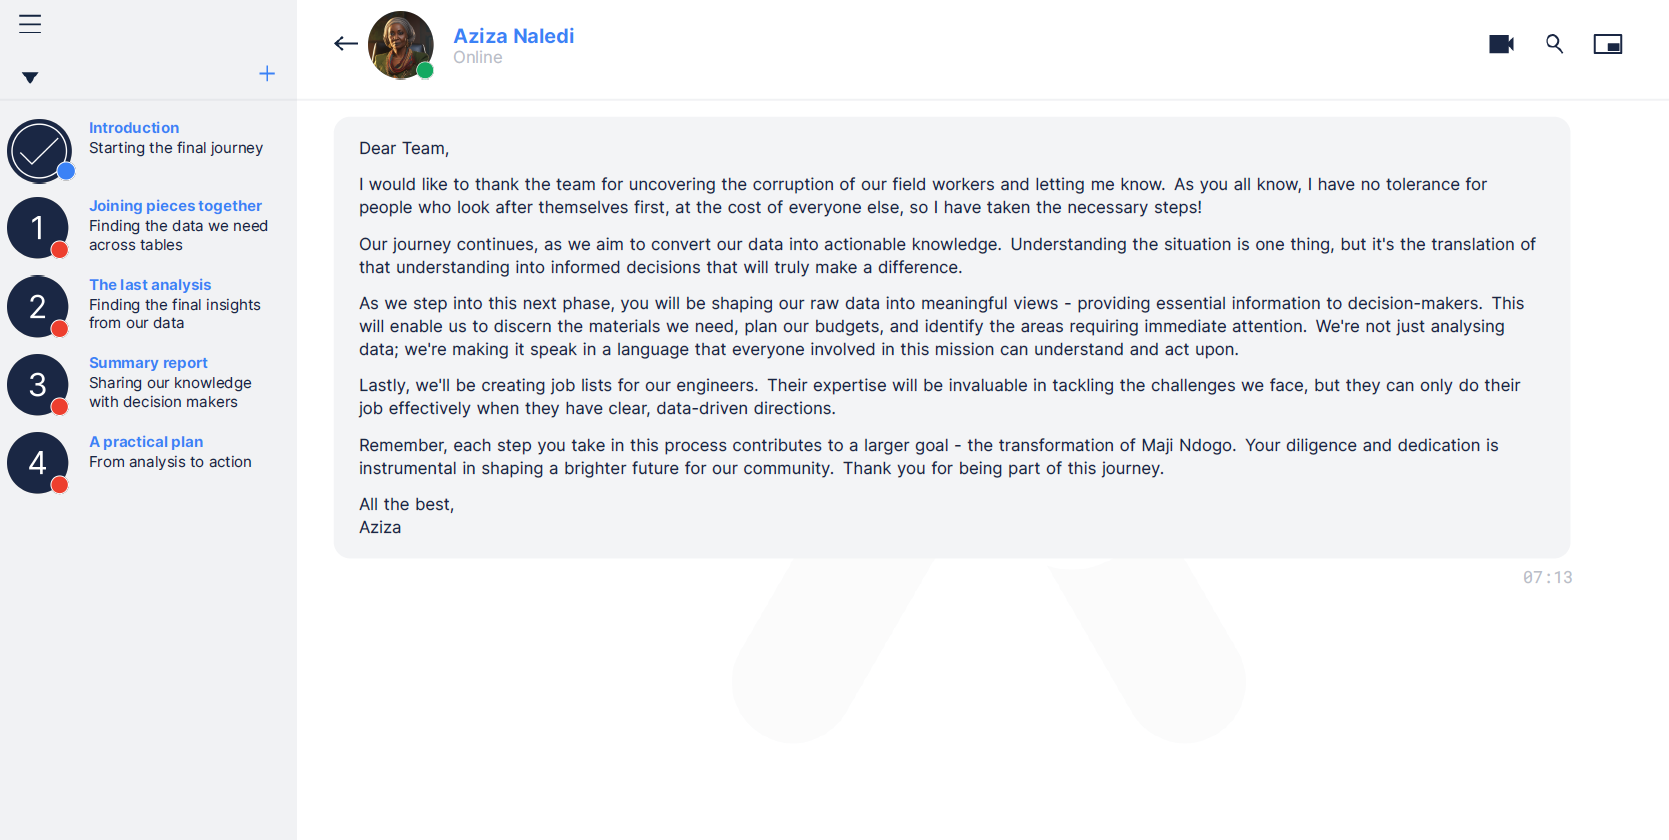

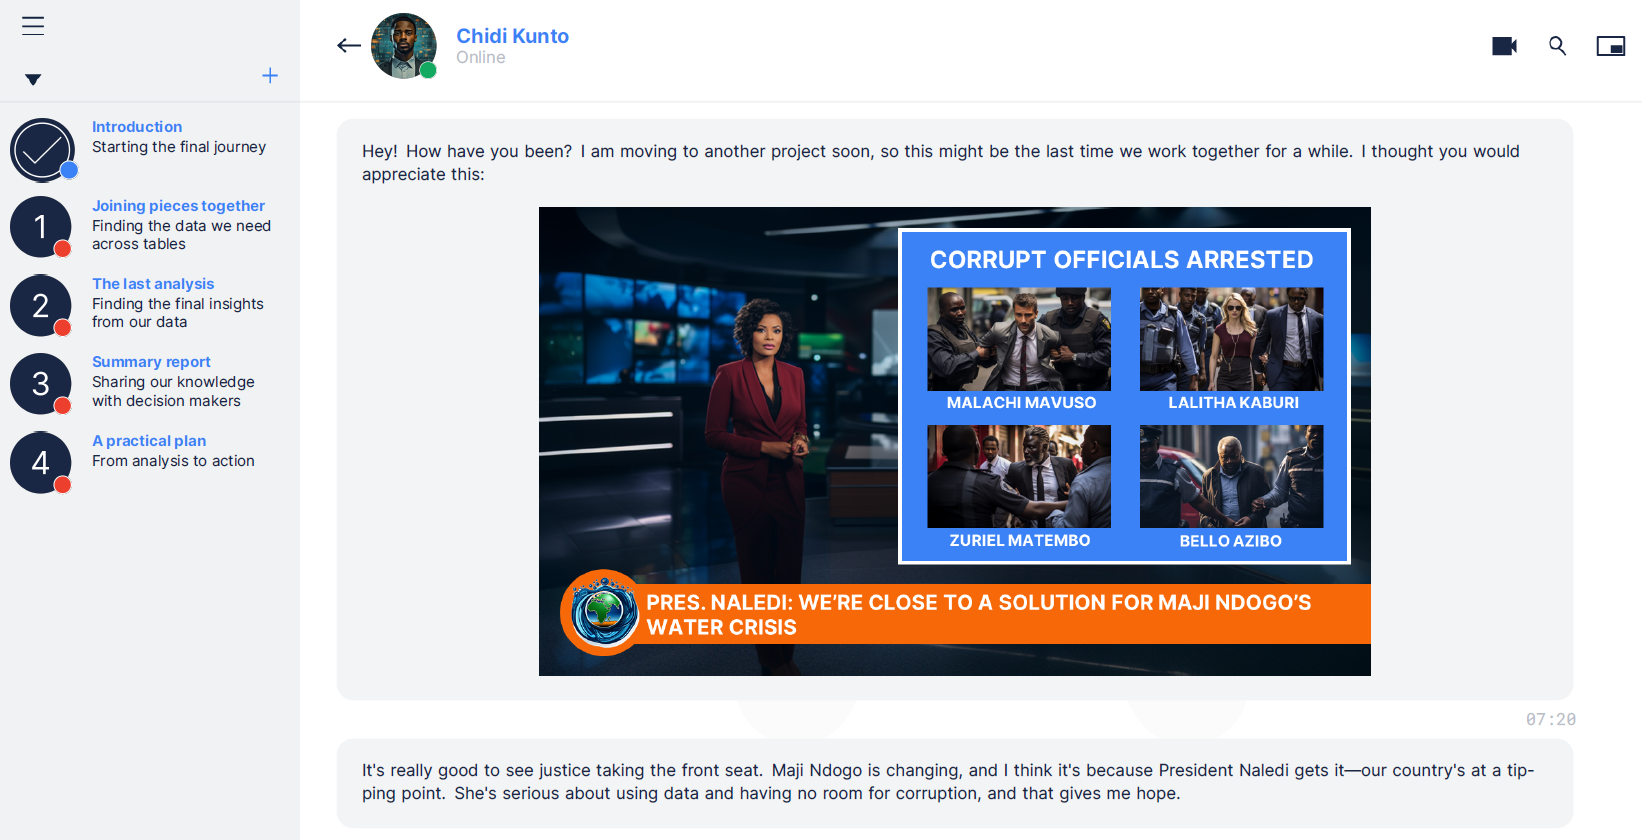

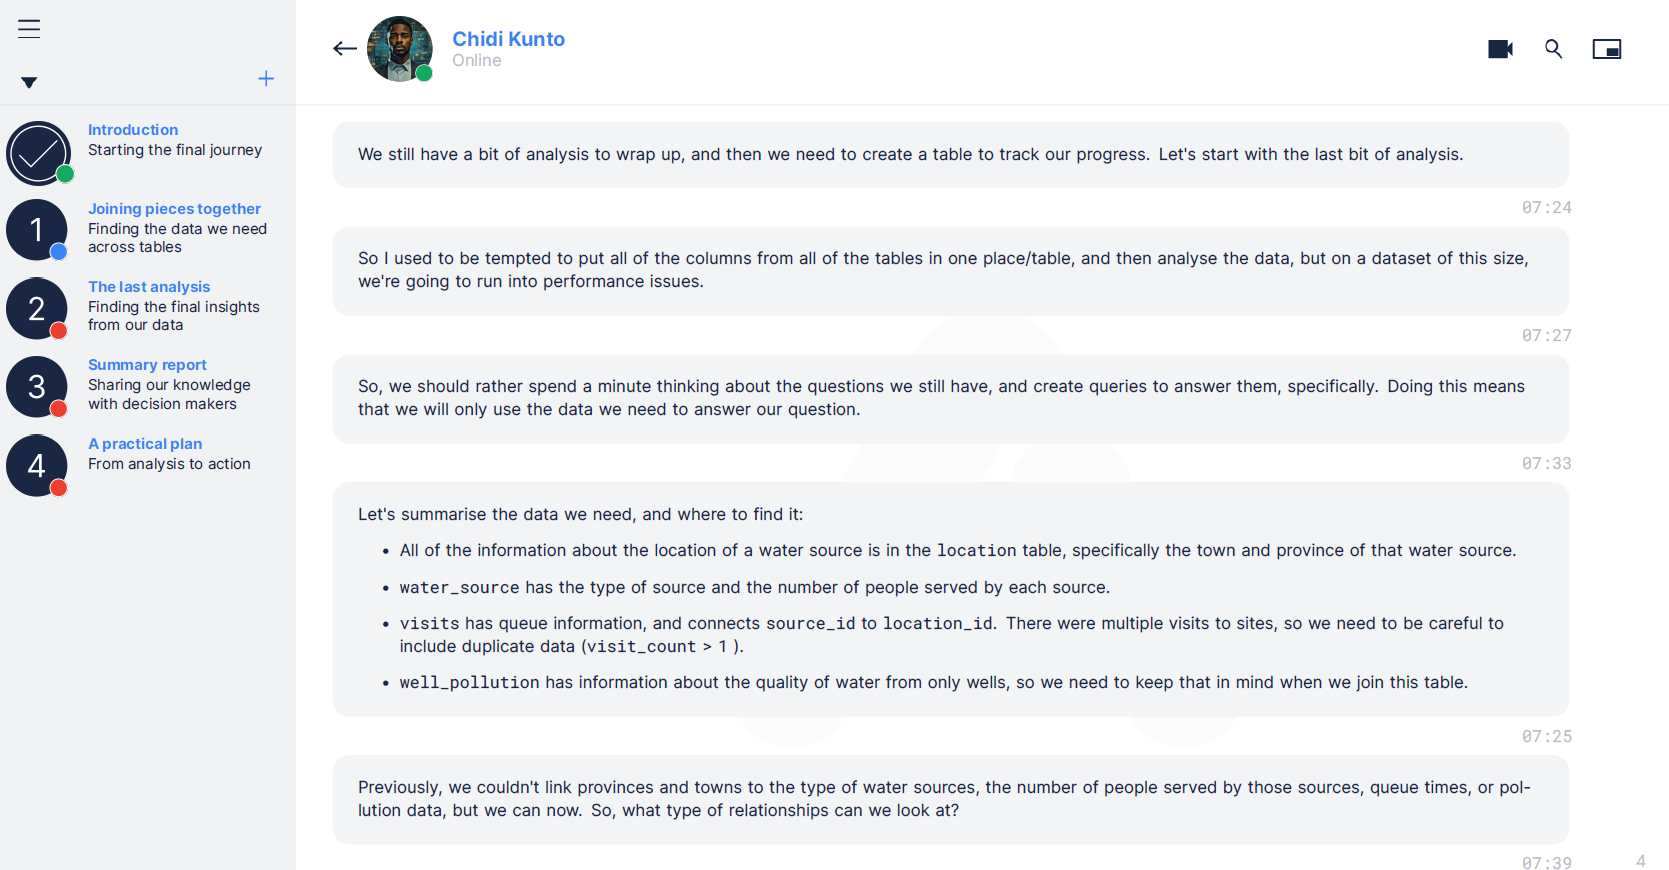

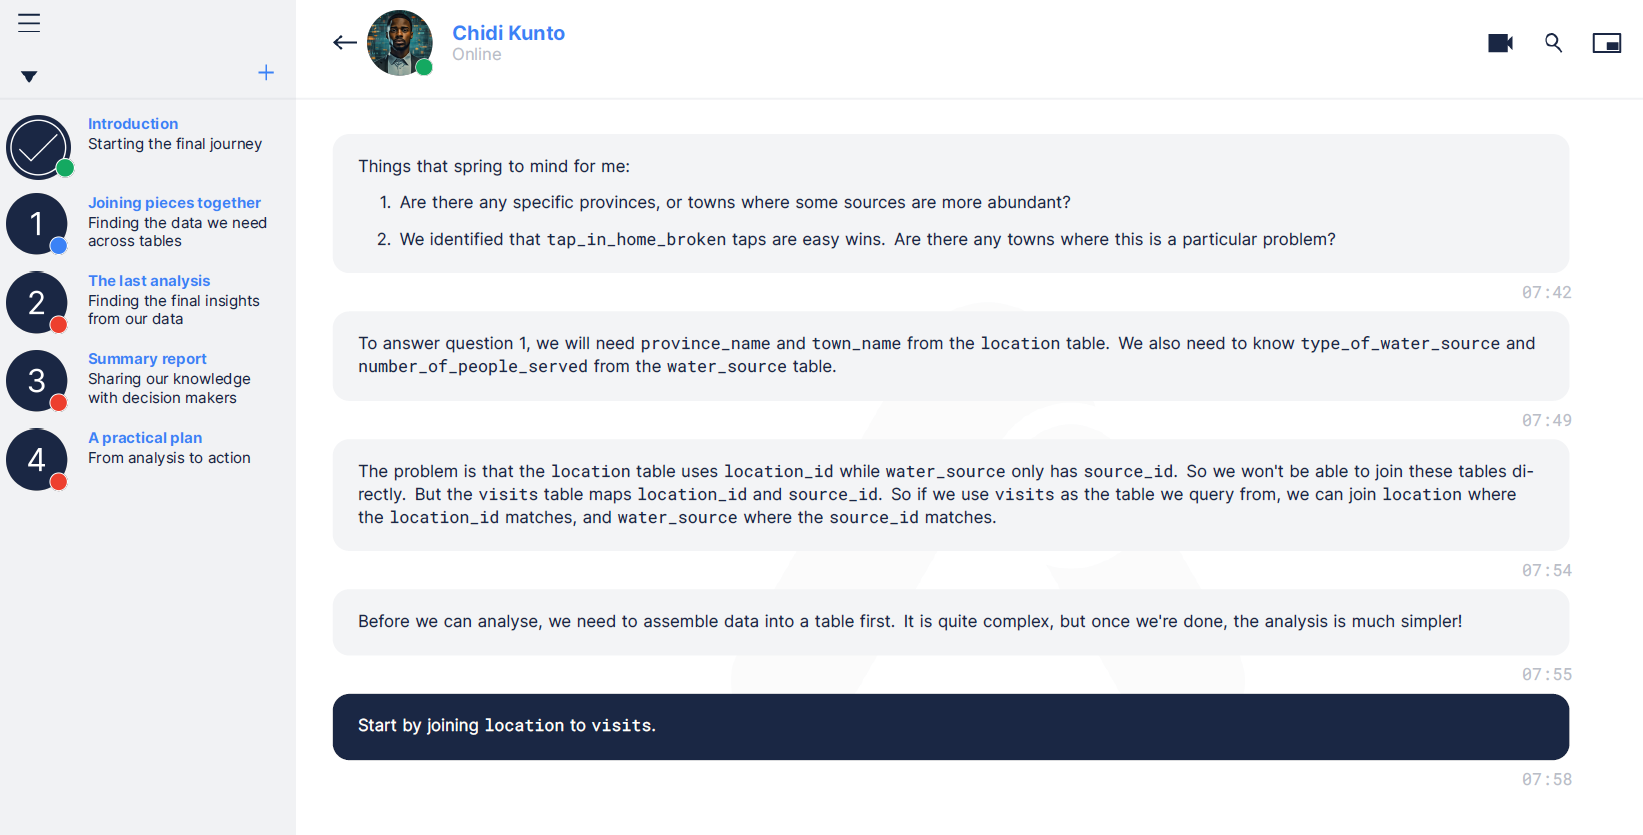

In [ ]:
%%sql
SELECT L.*, V.* FROM location L JOIN visits V  ON L.location_id = V.location_id LIMIT 5;

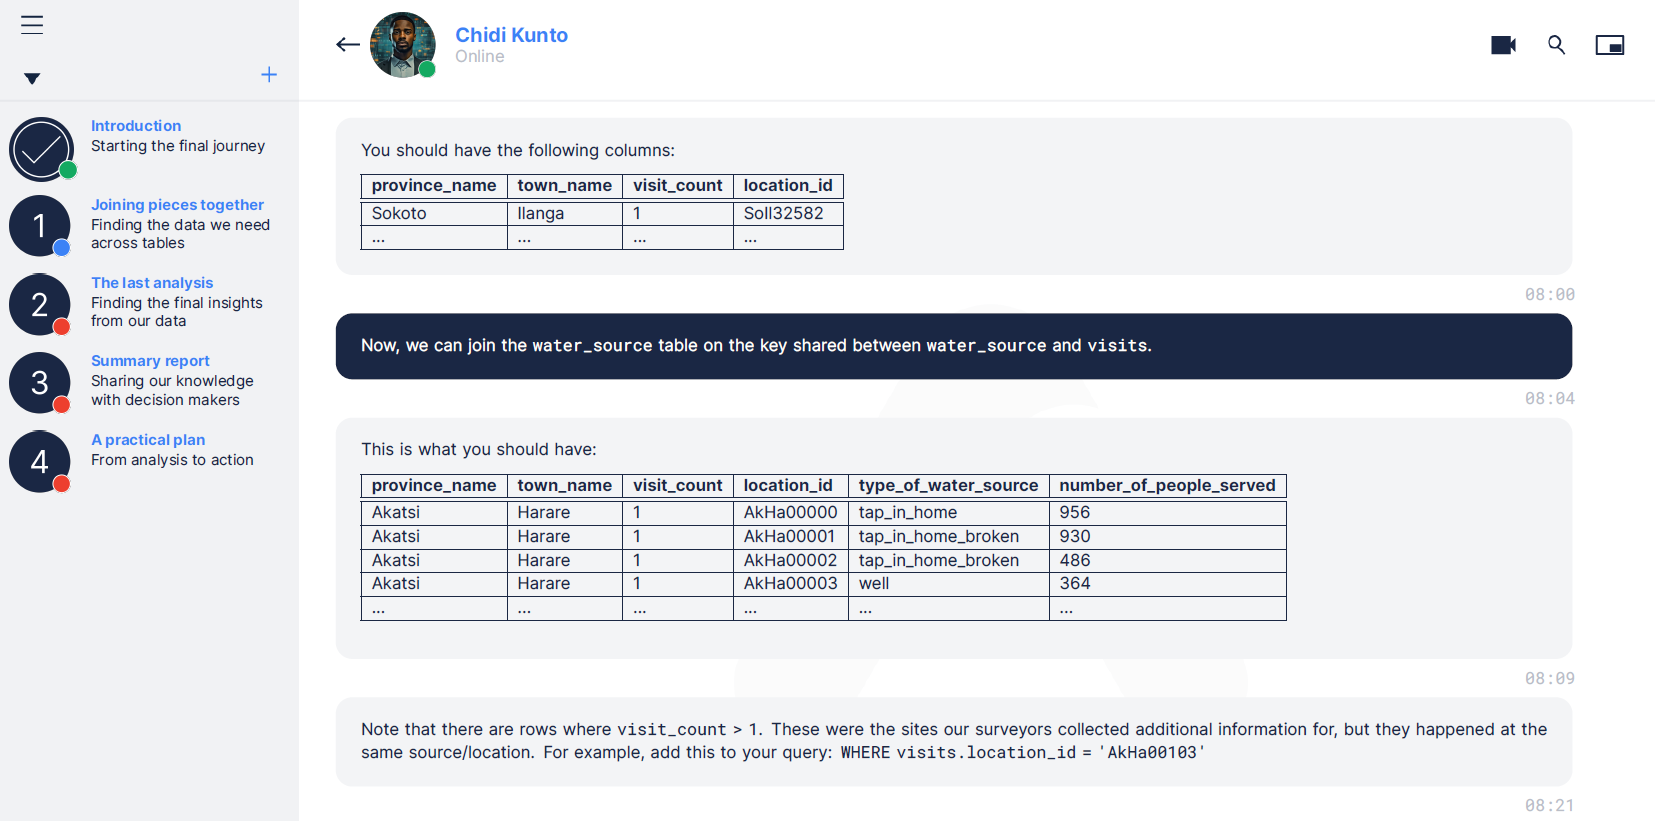

In [ ]:
%%sql
SELECT 
    L.province_name, 
    L.town_name, 
    V.visit_count, 
    L.location_id 
FROM location L 
JOIN visits V  ON L.location_id = V.location_id LIMIT 5;

In [ ]:
%%sql
SELECT 
    L.province_name, 
    L.town_name, 
    V.visit_count, 
    L.location_id,
    W.type_of_water_source,
    W.number_of_people_served 
FROM location L 
JOIN visits V  ON L.location_id = V.location_id 
JOIN water_source W ON W.source_id = V.source_id 
WHERE L.location_id = 'AkHa00103';

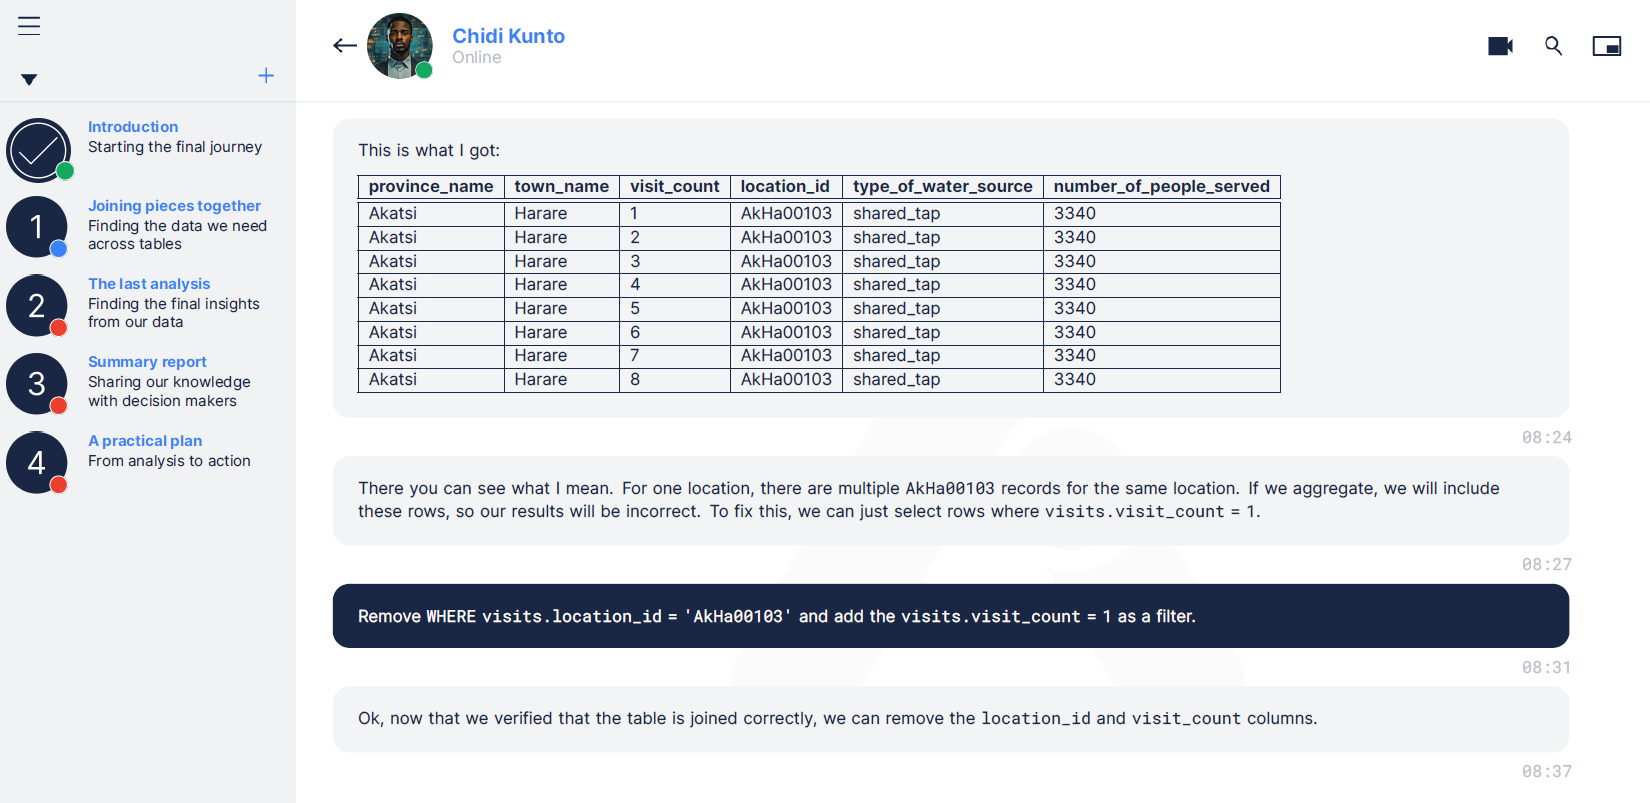

In [ ]:
%%sql
SELECT 
    L.province_name, 
    L.town_name, 
    V.visit_count, 
    L.location_id,
    W.type_of_water_source,
    W.number_of_people_served 
FROM location L 
JOIN visits V  ON L.location_id = V.location_id 
JOIN water_source W ON W.source_id = V.source_id 
WHERE V.visit_count = 1 LIMIT 5;

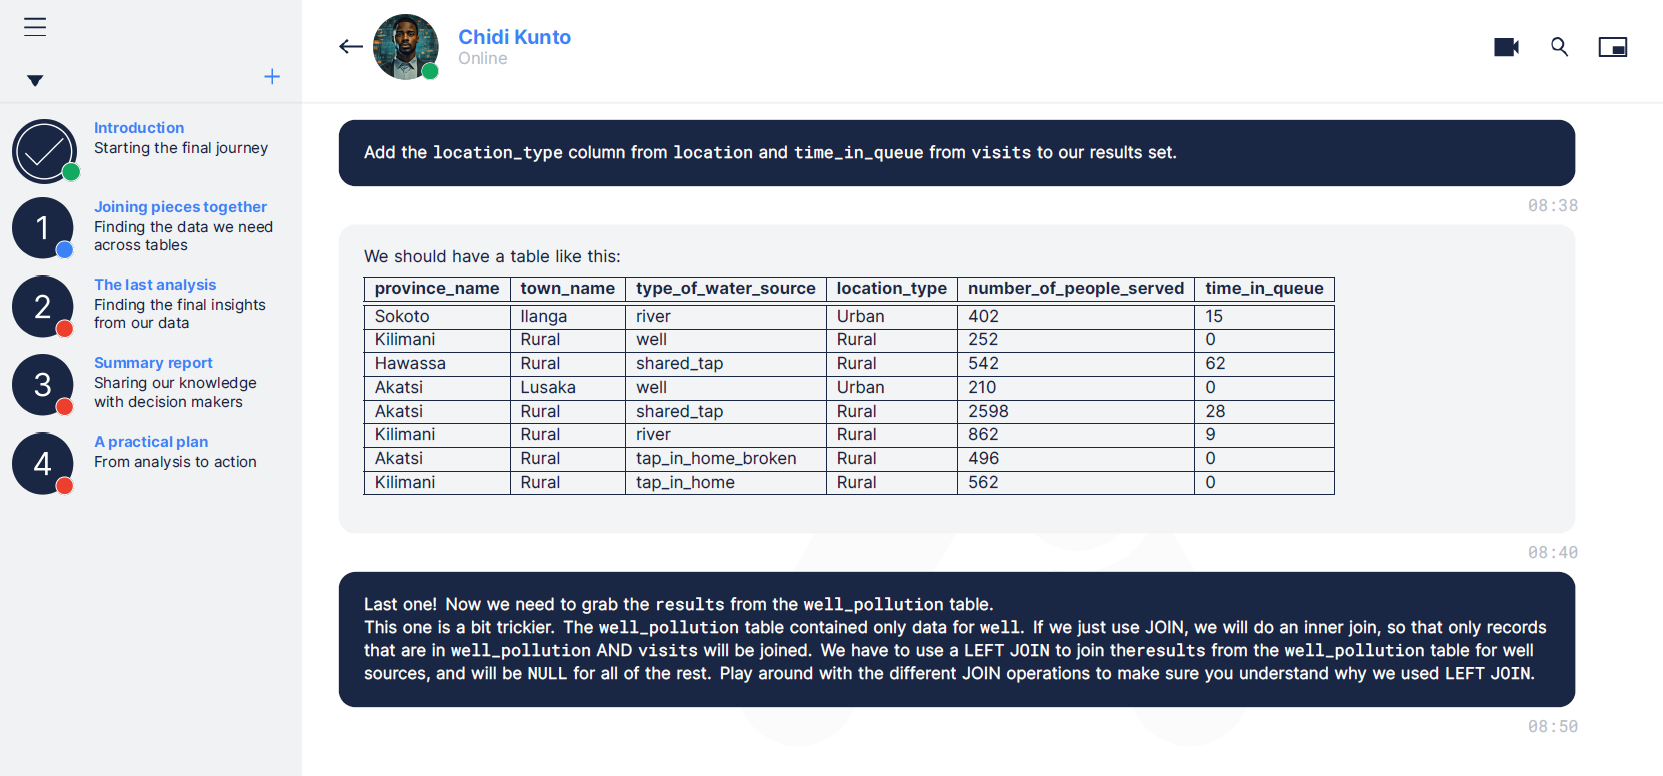

In [ ]:
%%sql
SELECT 
    L.province_name, 
    L.town_name, 
    W.type_of_water_source,
    L.location_type,
    W.number_of_people_served,
    V.time_in_queue,
    WP.results 
FROM location L 
JOIN visits V  ON L.location_id = V.location_id 
JOIN water_source W ON W.source_id = V.source_id 
LEFT JOIN well_pollution WP ON WP.source_id = W.source_id
WHERE V.visit_count = 1 LIMIT 5;

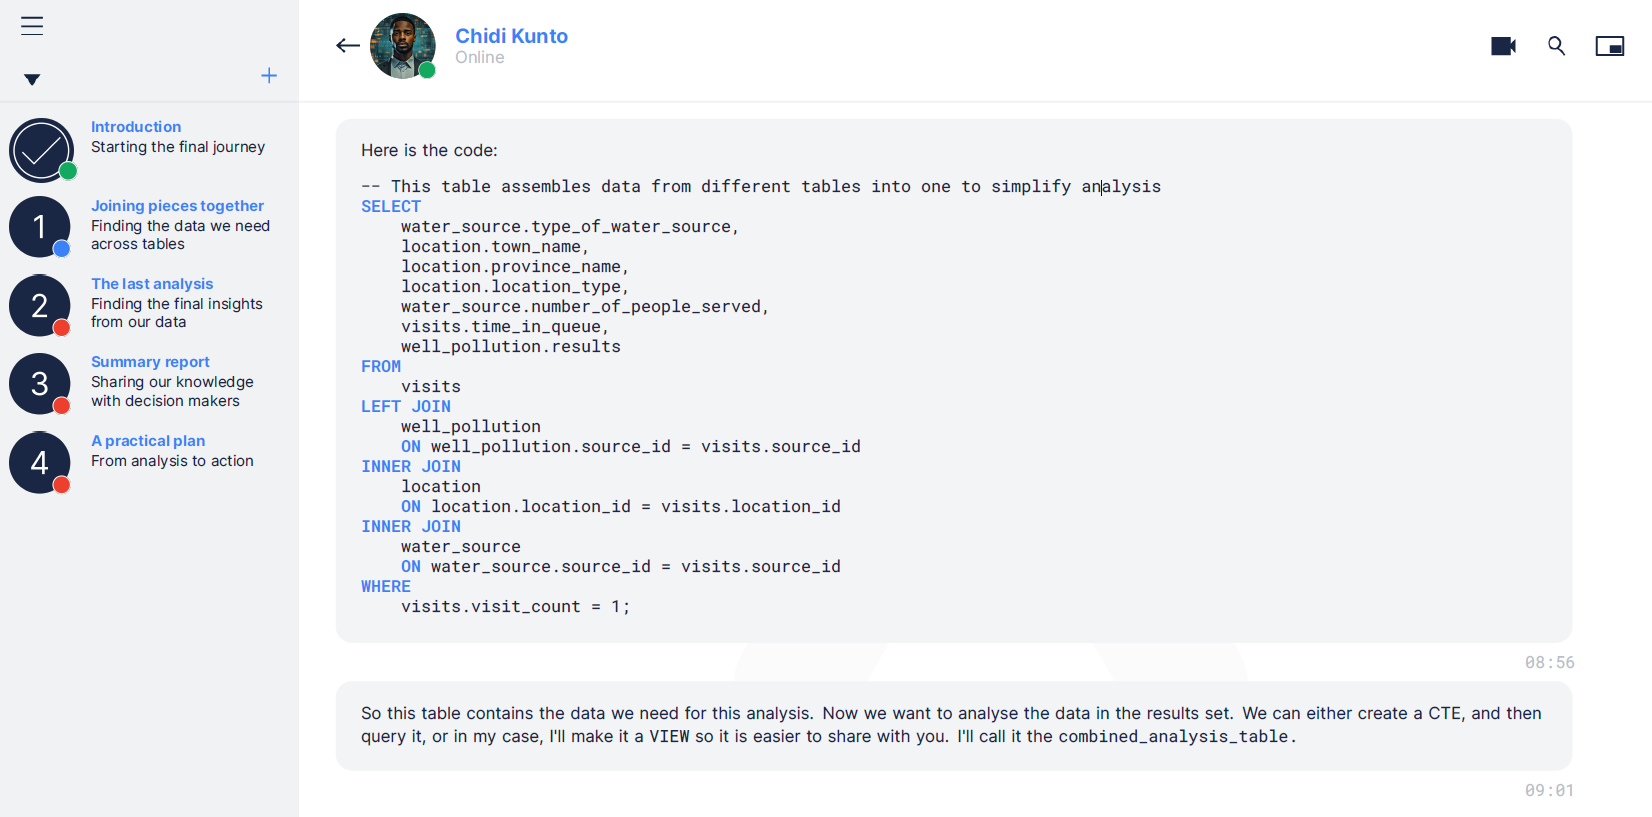

In [ ]:
%%sql
CREATE VIEW combined_analysis_table AS  
SELECT 
    L.province_name, 
    L.town_name, 
    W.type_of_water_source,
    L.location_type,
    W.number_of_people_served,
    V.time_in_queue,
    WP.results 
FROM location L 
JOIN visits V  ON L.location_id = V.location_id 
JOIN water_source W ON W.source_id = V.source_id 
LEFT JOIN well_pollution WP ON WP.source_id = W.source_id
WHERE V.visit_count = 1;

In [ ]:
%%sql 
SELECT * FROM combined_analysis_table LIMIT 5;

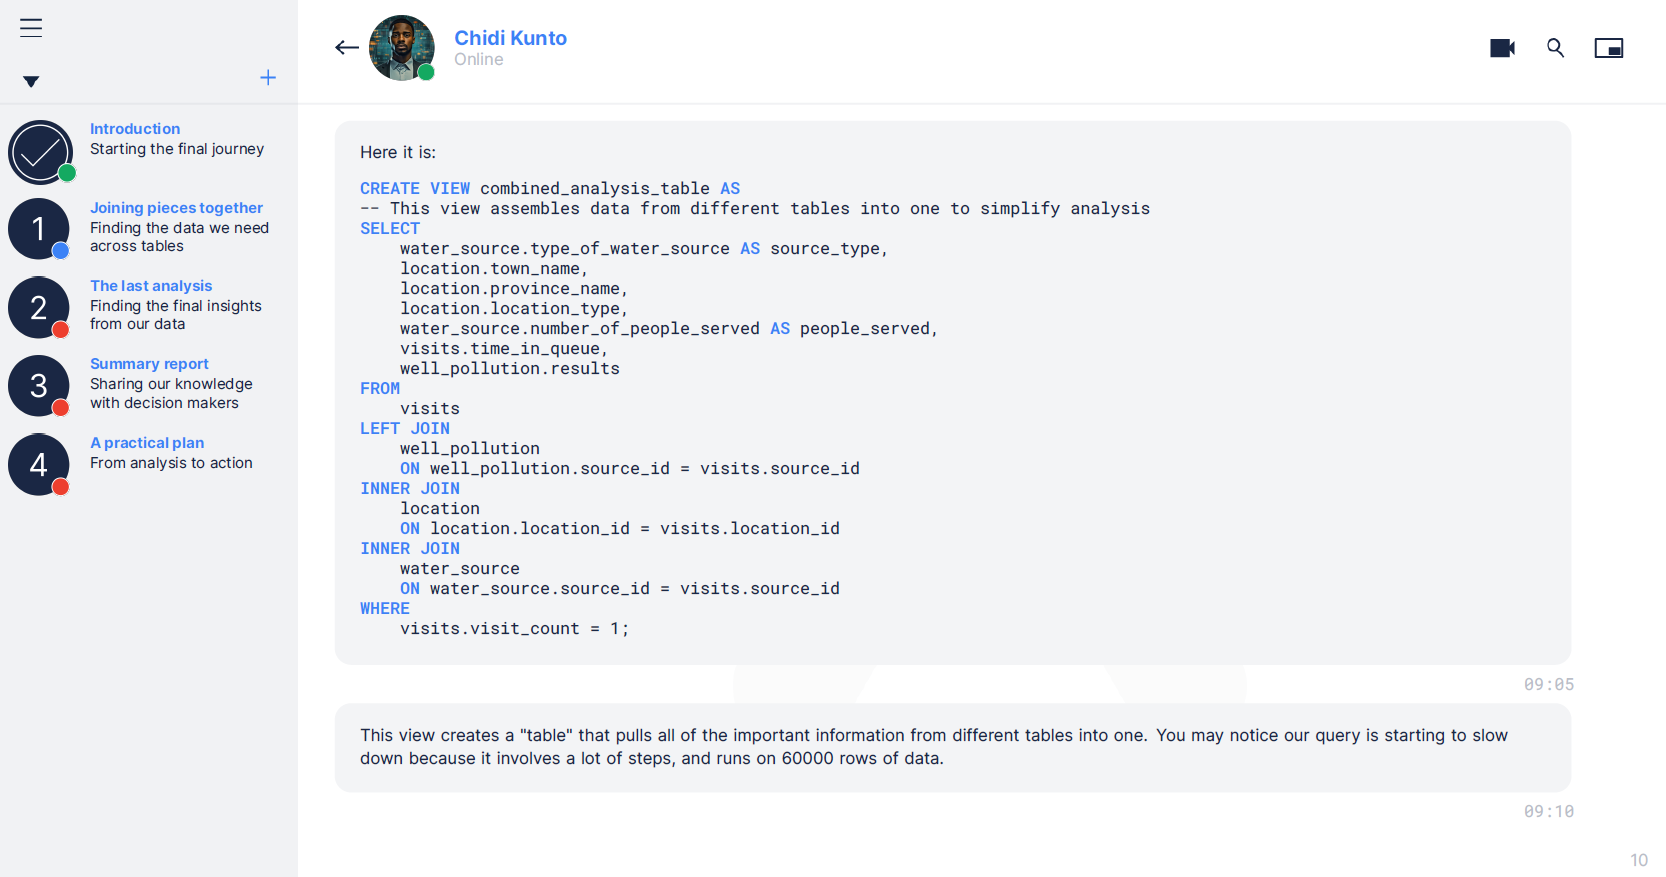

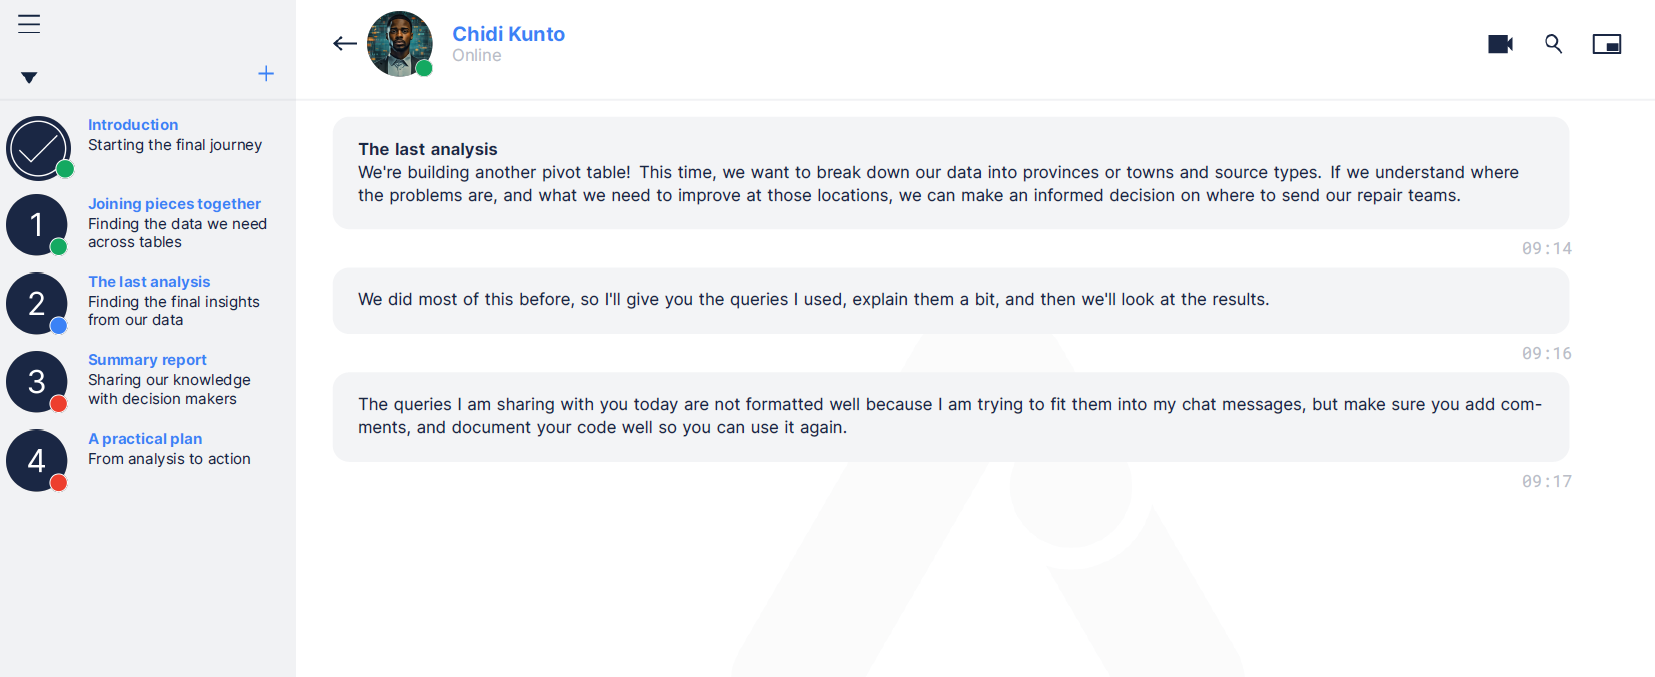

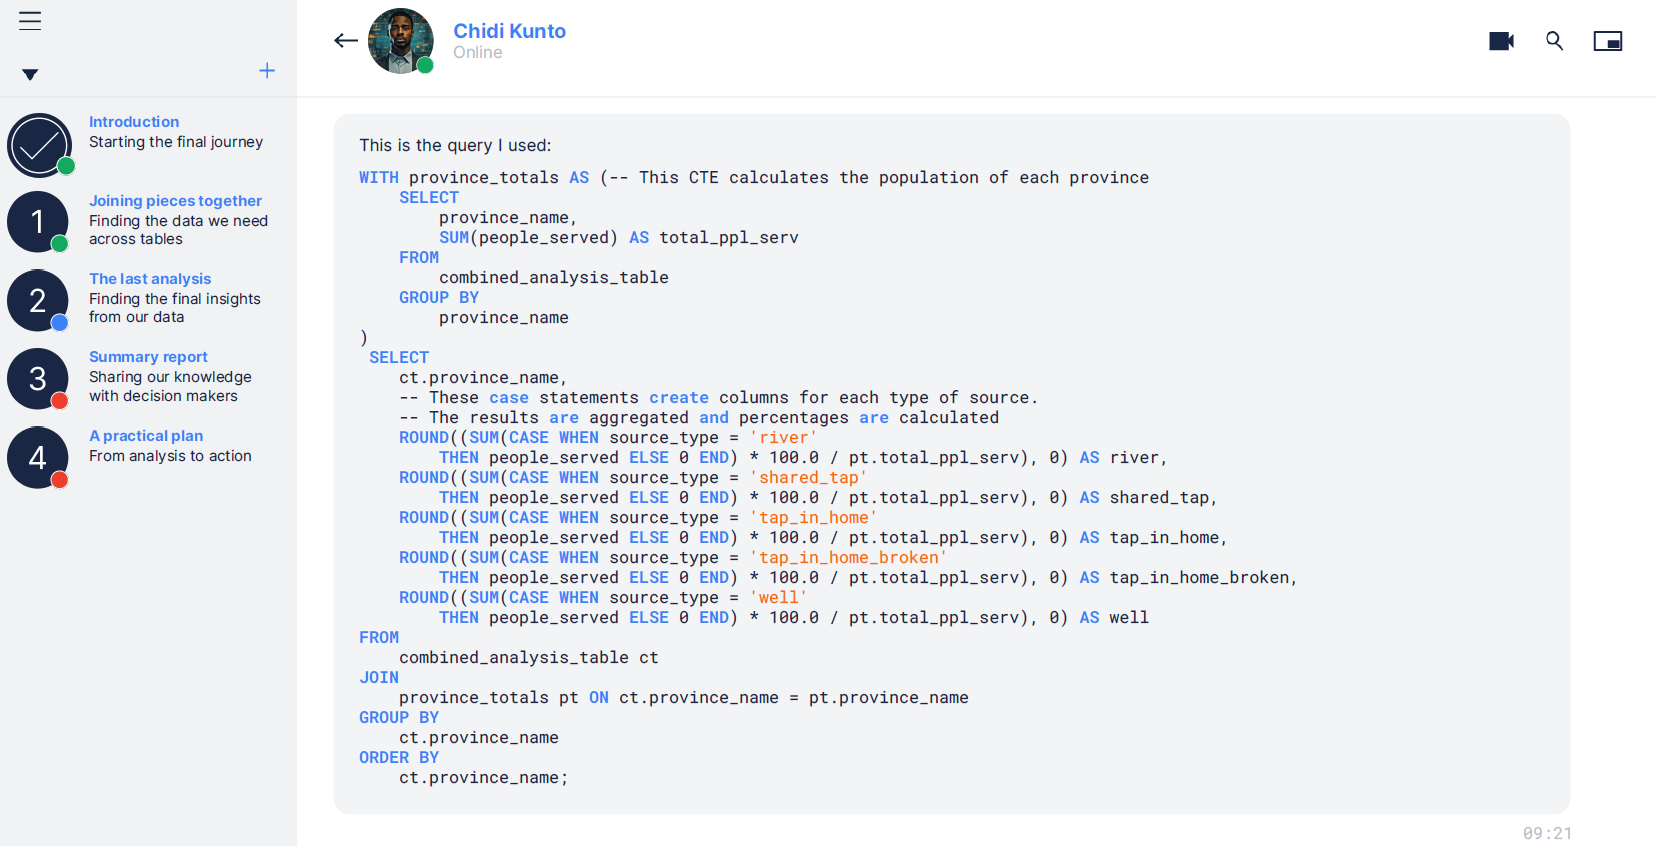

In [ ]:
%%sql
WITH province_totals AS (  -- This CTE calculates the population of each province
    SELECT
        province_name,
        SUM(people_served) AS total_ppl_serv
    FROM combined_analysis_table
    GROUP BY province_name
)
SELECT
    ct.province_name,

    -- These CASE statements create columns for each type of source.
    -- The results are aggregated and percentages are calculated.
    ROUND(
        (SUM(CASE WHEN source_type = 'river' THEN people_served ELSE 0 END) 
        * 100.0 / pt.total_ppl_serv), 0
    ) AS river,
    ROUND(
        (SUM(CASE WHEN source_type = 'shared_tap' THEN people_served ELSE 0 END) 
        * 100.0 / pt.total_ppl_serv), 0
    ) AS shared_tap,
    ROUND(
        (SUM(CASE WHEN source_type = 'tap_in_home' THEN people_served ELSE 0 END) 
        * 100.0 / pt.total_ppl_serv), 0
    ) AS tap_in_home,
    ROUND(
        (SUM(CASE WHEN source_type = 'tap_in_home_broken' THEN people_served ELSE 0 END) 
        * 100.0 / pt.total_ppl_serv), 0
    ) AS tap_in_home_broken,
    ROUND(
        (SUM(CASE WHEN source_type = 'well' THEN people_served ELSE 0 END) 
        * 100.0 / pt.total_ppl_serv), 0
    ) AS well
FROM combined_analysis_table ct
JOIN province_totals pt 
    ON ct.province_name = pt.province_name
GROUP BY ct.province_name
ORDER BY ct.province_name;

# END OF PART 4 